# Errores N-BEATS


Este notebook calcula MAE, RMSE y MAPE para los forecasts N-BEATS guardados por la aplicacion en `~/Energy Forecast app/models/...`. Los archivos de forecast contienen `timestamp,yhat`, por lo que se cruzan con `~/Energy Forecast app/data/processed/AT.csv` para recuperar los valores reales `y` antes de exportar las metricas.


Importamos las dependencias necesarias para leer los runs N-BEATS, unirlos con la serie real, calcular metricas, exportar resultados y graficar.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)


Definimos la ruta del workspace externo, el dataset procesado y el mapeo de cada experimento al run N-BEATS correspondiente.


In [2]:
DATASET_NAME = "AT"
NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
ARTIFACTS_DIR = NOTEBOOK_DIR / "artifacts"
OUTPUT_DIR = ARTIFACTS_DIR / "comparison"
APP_ROOT = Path.home() / "Energy Forecast app"
SOURCE_FILE = APP_ROOT / "data" / "processed" / f"{DATASET_NAME}.csv"

EXPERIMENTS = [
    {"name": "daily", "label": "24 horas", "horizon": 24, "input_size": 168},
    {"name": "weekly", "label": "168 horas", "horizon": 168, "input_size": 672},
    {"name": "biweekly", "label": "336 horas", "horizon": 336, "input_size": 1344},
    {"name": "monthly", "label": "720 horas", "horizon": 720, "input_size": 2160},
]

NBEATS_RUNS = {
    "daily": APP_ROOT / "models" / "mdl_aW0ztzu4" / "runs" / "run_chiPivcP" / "forecast.csv",
    "weekly": APP_ROOT / "models" / "mdl_Wc39AOOV" / "runs" / "run_KH91IXzZ" / "forecast.csv",
    "biweekly": APP_ROOT / "models" / "mdl_M3MkztXB" / "runs" / "run_tTPEOWzE" / "forecast.csv",
    "monthly": APP_ROOT / "models" / "mdl_dQr1gCxu" / "runs" / "run_9CMhT3Ix" / "forecast.csv",
}

SOURCE_FILE, OUTPUT_DIR


(PosixPath('/home/albert/Energy Forecast app/data/processed/AT.csv'),
 PosixPath('/home/albert/projects/nbeats-forecasting/notebooks/artifacts/comparison'))

Cargamos la serie real procesada con el contrato `timestamp,y`, validando timestamps UTC, valores numericos y ausencia de duplicados por timestamp.


In [3]:
if not SOURCE_FILE.exists():
    raise FileNotFoundError(f"No se encontro el dataset procesado: {SOURCE_FILE}")

actual_series = pd.read_csv(SOURCE_FILE, usecols=["timestamp", "y"])
actual_series["timestamp"] = pd.to_datetime(actual_series["timestamp"], utc=True, errors="coerce")
actual_series["y"] = pd.to_numeric(actual_series["y"], errors="coerce")
actual_series = actual_series.dropna(subset=["timestamp", "y"]).sort_values("timestamp").reset_index(drop=True)

if actual_series["timestamp"].duplicated().any():
    raise ValueError("La serie real contiene timestamps duplicados.")

actual_series.head()


,timestamp,y
0,2015-01-01 00:00:00+00:00,5946.0
1,2015-01-01 01:00:00+00:00,5726.0
2,2015-01-01 02:00:00+00:00,5347.0
3,2015-01-01 03:00:00+00:00,5249.0
4,2015-01-01 04:00:00+00:00,5309.0


Estas funciones normalizan los forecasts N-BEATS al contrato `timestamp,y,yhat` y calculan las metricas de error usadas en la comparacion.


In [4]:
def display_path(path: Path) -> str:
    if path.is_relative_to(APP_ROOT):
        return f"~/Energy Forecast app/{path.relative_to(APP_ROOT)}"
    return str(path)

def forecast_metrics(actual: pd.Series, predicted: pd.Series) -> dict[str, float]:
    actual_values = actual.astype(float).to_numpy()
    predicted_values = predicted.astype(float).to_numpy()
    errors = actual_values - predicted_values
    nonzero_mask = actual_values != 0
    mape = np.nan if not nonzero_mask.any() else np.mean(np.abs(errors[nonzero_mask] / actual_values[nonzero_mask])) * 100

    return {
        "mae": float(np.mean(np.abs(errors))),
        "rmse": float(np.sqrt(np.mean(errors**2))),
        "mape": float(mape),
    }

def load_nbeats_forecast(path: Path, experiment: dict) -> pd.DataFrame:
    forecast = pd.read_csv(path)
    required_columns = {"timestamp", "yhat"}
    missing_columns = required_columns.difference(forecast.columns)
    if missing_columns:
        missing = ", ".join(sorted(missing_columns))
        raise ValueError(f"{path} no tiene columnas requeridas: {missing}")

    forecast = forecast.loc[:, ["timestamp", "yhat"]].copy()
    forecast["timestamp"] = pd.to_datetime(forecast["timestamp"], utc=True, errors="coerce")
    forecast["yhat"] = pd.to_numeric(forecast["yhat"], errors="coerce")
    forecast = forecast.dropna(subset=["timestamp", "yhat"]).sort_values("timestamp").reset_index(drop=True)
    forecast = forecast.merge(actual_series, on="timestamp", how="left")

    if forecast["y"].isna().any():
        raise ValueError(f"No se encontraron valores reales para todos los timestamps de {path}")
    if len(forecast) != experiment["horizon"]:
        raise ValueError(f"{path} tiene {len(forecast)} filas, se esperaban {experiment['horizon']}")

    forecast = forecast.loc[:, ["timestamp", "y", "yhat"]]
    forecast["dataset"] = DATASET_NAME
    forecast["model"] = "N-BEATS"
    forecast["experiment"] = experiment["name"]
    forecast["label"] = experiment["label"]
    forecast["horizon"] = experiment["horizon"]
    forecast["input_size"] = experiment["input_size"]
    forecast["source_path"] = display_path(path)
    return forecast


Cargamos los cuatro forecasts N-BEATS desde las carpetas de runs y mostramos el rango temporal evaluado por cada horizonte.


In [5]:
forecasts = []
missing_files = []

for experiment in EXPERIMENTS:
    path = NBEATS_RUNS[experiment["name"]]
    if not path.exists():
        missing_files.append({"model": "N-BEATS", "experiment": experiment["name"], "path": display_path(path)})
        continue
    forecasts.append(load_nbeats_forecast(path, experiment))

if not forecasts:
    raise FileNotFoundError("No se encontraron forecasts N-BEATS en ~/Energy Forecast app/models.")

loaded_summary = pd.DataFrame([
    {
        "experiment": forecast["experiment"].iloc[0],
        "horizon": int(forecast["horizon"].iloc[0]),
        "input_size": int(forecast["input_size"].iloc[0]),
        "rows": len(forecast),
        "start": forecast["timestamp"].iloc[0],
        "end": forecast["timestamp"].iloc[-1],
        "source_path": forecast["source_path"].iloc[0],
    }
    for forecast in forecasts
])
loaded_summary


,experiment,horizon,input_size,rows,start,end,source_path
0,daily,24,168,24,2019-01-08 00:00:00+00:00,2019-01-08 23:00:00+00:00,~/Energy Forecast app/models/mdl_aW0ztzu4/runs...
1,weekly,168,672,168,2019-01-29 00:00:00+00:00,2019-02-04 23:00:00+00:00,~/Energy Forecast app/models/mdl_Wc39AOOV/runs...
2,biweekly,336,1344,336,2019-02-26 00:00:00+00:00,2019-03-11 23:00:00+00:00,~/Energy Forecast app/models/mdl_M3MkztXB/runs...
3,monthly,720,2160,720,2019-04-01 00:00:00+00:00,2019-04-30 23:00:00+00:00,~/Energy Forecast app/models/mdl_dQr1gCxu/runs...


Calculamos las metricas por horizonte usando los valores reales recuperados del dataset procesado y los pronosticos de cada run N-BEATS.


In [6]:
metric_rows = []

for forecast in forecasts:
    metrics = forecast_metrics(forecast["y"], forecast["yhat"])
    metric_rows.append({
        "dataset": forecast["dataset"].iloc[0],
        "model": forecast["model"].iloc[0],
        "experiment": forecast["experiment"].iloc[0],
        "label": forecast["label"].iloc[0],
        "horizon": int(forecast["horizon"].iloc[0]),
        "input_size": int(forecast["input_size"].iloc[0]),
        "test_rows": len(forecast),
        "test_start": forecast["timestamp"].iloc[0].isoformat(),
        "test_end": forecast["timestamp"].iloc[-1].isoformat(),
        "source_path": forecast["source_path"].iloc[0],
        **metrics,
    })

metrics_df = pd.DataFrame(metric_rows).sort_values("horizon").reset_index(drop=True)
metrics_df


,dataset,model,experiment,label,horizon,input_size,test_rows,test_start,test_end,source_path,mae,rmse,mape
0,AT,N-BEATS,daily,24 horas,24,168,24,2019-01-08T00:00:00+00:00,2019-01-08T23:00:00+00:00,~/Energy Forecast app/models/mdl_aW0ztzu4/runs...,275.984075,343.681933,2.963136
1,AT,N-BEATS,weekly,168 horas,168,672,168,2019-01-29T00:00:00+00:00,2019-02-04T23:00:00+00:00,~/Energy Forecast app/models/mdl_Wc39AOOV/runs...,335.393114,418.004382,4.212377
2,AT,N-BEATS,biweekly,336 horas,336,1344,336,2019-02-26T00:00:00+00:00,2019-03-11T23:00:00+00:00,~/Energy Forecast app/models/mdl_M3MkztXB/runs...,235.349439,290.537794,3.090816
3,AT,N-BEATS,monthly,720 horas,720,2160,720,2019-04-01T00:00:00+00:00,2019-04-30T23:00:00+00:00,~/Energy Forecast app/models/mdl_dQr1gCxu/runs...,625.891041,792.432388,9.573416


Exportamos las metricas N-BEATS y los forecasts normalizados para que la comparacion final pueda leer resultados ya calculados.


In [7]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
metrics_path = OUTPUT_DIR / f"{DATASET_NAME.lower()}_nbeats_error_metrics.csv"
missing_path = OUTPUT_DIR / f"{DATASET_NAME.lower()}_nbeats_missing_forecasts.csv"
normalized_path = OUTPUT_DIR / f"{DATASET_NAME.lower()}_nbeats_normalized_forecasts.csv"

metrics_df.to_csv(metrics_path, index=False)
pd.DataFrame(missing_files).to_csv(missing_path, index=False)
pd.concat(forecasts, ignore_index=True).to_csv(normalized_path, index=False)

print(f"metrics: {metrics_path.relative_to(NOTEBOOK_DIR)}")
print(f"missing: {missing_path.relative_to(NOTEBOOK_DIR)}")
print(f"normalized forecasts: {normalized_path.relative_to(NOTEBOOK_DIR)}")


metrics: artifacts/comparison/at_nbeats_error_metrics.csv
missing: artifacts/comparison/at_nbeats_missing_forecasts.csv
normalized forecasts: artifacts/comparison/at_nbeats_normalized_forecasts.csv


Graficamos cada forecast N-BEATS contra sus valores reales para revisar visualmente la escala y el tramo evaluado.


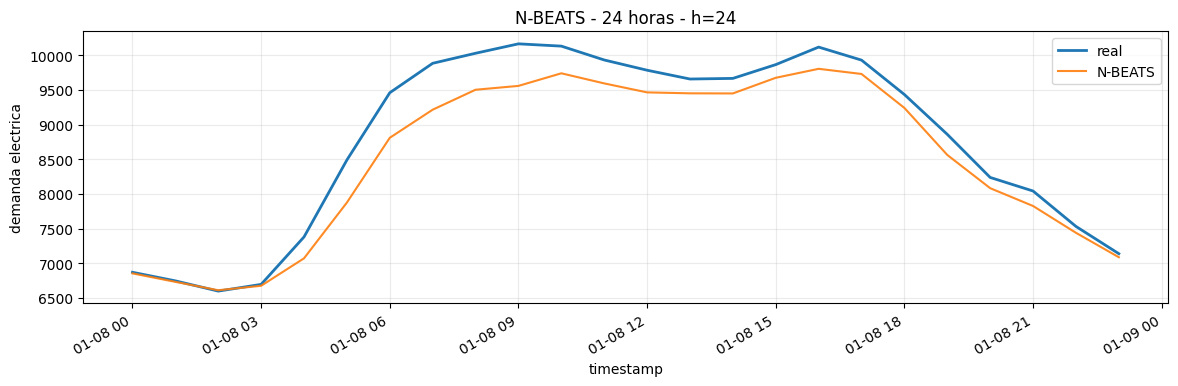

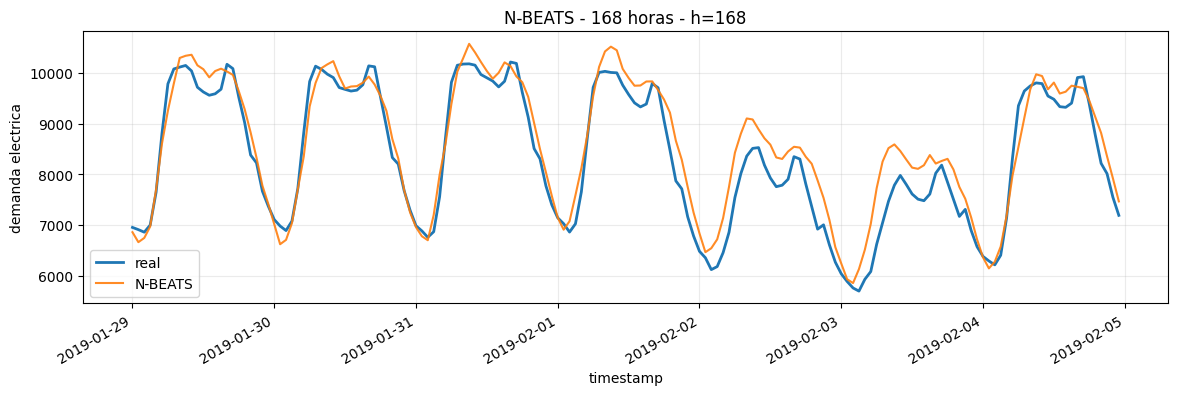

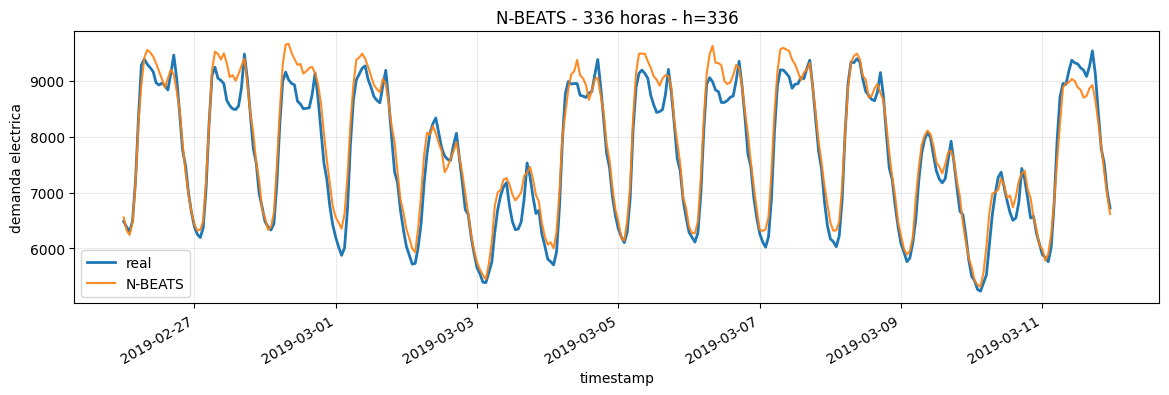

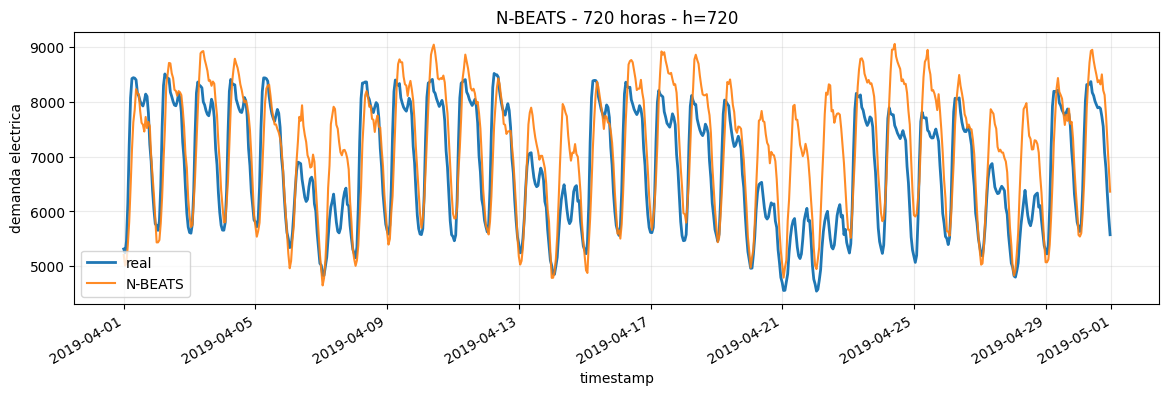

In [8]:
for forecast in forecasts:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(forecast["timestamp"], forecast["y"], label="real", linewidth=2)
    ax.plot(forecast["timestamp"], forecast["yhat"], label="N-BEATS", alpha=0.9)
    ax.set_title(f"N-BEATS - {forecast['label'].iloc[0]} - h={int(forecast['horizon'].iloc[0])}")
    ax.set_xlabel("timestamp")
    ax.set_ylabel("demanda electrica")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.autofmt_xdate()
    plt.show()
